# Compare embedding models and LLMs for item parameter prediction

A 2 × 2 factorial experiment on the leave-one-out predictions of `predict_item_parameters.ipynb`: how much do the embedding model that finds an item's reference items, the LLM that predicts its IRT parameters, and their combination change how well the parameters of the 722 calibrated released items are predicted?

| Factor | First level (the reference) | Second level |
| --- | --- | --- |
| Embedding model (`embedding_model`) | `gemini-embedding-001` through the Gemini API, 768 dimensions, as in `predict_item_parameters.ipynb` | FastEmbed's default `BAAI/bge-small-en-v1.5` on this computer, 384 dimensions, as in `predict_item_parameters_FastEmbed.ipynb` |
| LLM (`llm`) | `google/gemini-3.8-flash` through OpenRouter, with medium reasoning effort | `llama3.2` in a local Ollama server, without reasoning |

Everything else is the same in the four conditions: the 722 calibrated items, hybrid search for the reference items (the 10 most similar calibrated items of the item's grade, plus up to 5 of the most similar items with its IRT model and points), the prompts, and the leave-one-out rule that keeps an item's other parts and the other items of its task out of its context.
The embedding model changes which reference items an item gets, and so its user prompt; the keyword half of hybrid search is the same with both.

The code is in the `timss_math.item_parameter_prediction` modules (`src/timss_math/item_parameter_prediction/`, see the README); `FactorialResults` (in `factorial`) combines the four leave-one-out runs.

1. Set up the four conditions and find which of their predictions are saved.
2. Request the missing predictions, or only use the saved ones.
3. Combine the runs: each item parameter's prediction and error in each condition.
4. Compare the conditions: mean absolute error, main effects and interaction, and a graph.
5. Export everything to `data/timss_math_predicted_item_parameters_compare.xlsx`.

In [1]:
import itertools
import logging
from pathlib import Path

import pandas as pd
from IPython.display import display

from timss_math.item_parameter_prediction import (
    EmbeddingSettings,
    FactorialResults,
    ItemBank,
    ItemIndex,
    LeaveOneOut,
    LLMSettings,
    ParameterPredictor,
    plots,
)
from timss_math.item_parameter_prediction.batch import BatchAPIError

# The modules report their progress through logging; one line per HTTP request would be too many.
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
for name in ("httpx", "httpx2"):  # openai sends through httpx2
    logging.getLogger(name).setLevel(logging.WARNING)

# The plots module draws matplotlib Figures without pyplot, so the inline backend must be turned on to show them.
%matplotlib inline

DATA_DIR = Path.cwd() / "data"

## The four conditions

`EMBEDDINGS` and `LLMS` name the levels of the two factors and hold their settings, which are those of the notebook each level comes from; the first level of each factor is the reference for the effects below.

- `gemini-embedding-001` is `EmbeddingSettings()`, whose item embeddings are the ones `predict_item_parameters.ipynb` cached in `data/timss_math_item_embeddings.npz`.
- `bge-small-en-v1.5` embeds each text on its own with FastEmbed, as `predict_item_parameters_FastEmbed.ipynb` does, and its item embeddings are cached in `data/cache/item_embeddings/`.
- `gemini-3.8-flash` is `LLMSettings()`: `google/gemini-3.8-flash` through OpenRouter with medium reasoning effort and an output cap of 16,384 tokens.
- `llama3.2` gets no reasoning effort, since it cannot reason, and an output cap of 4,096 tokens, which stops a reply that repeats itself.

Both sets of item embeddings are cached, so building the two indexes embeds nothing and needs no API key, and a leave-one-out run reuses each item's stored vector, so it embeds nothing either.
Each index is kept in memory, so it never conflicts with the lock that the kernel of another notebook holds on a local Qdrant store.

Each condition is a `LeaveOneOut` run (see `predict_item_parameters_FastEmbed.ipynb` for what it does).
Predictions are saved per LLM in `data/cache/parameter_predictions/timss_math/<provider>/<model>/`, one file per item and prompt, named by the item and a hash of the LLM, its reasoning effort, and both prompts.
The two embedding models give an item different reference items, and so different prompts, so the two conditions of an LLM never share a file.
A condition reuses every prediction saved for its prompts, whichever notebook or command saved it: `gemini-embedding-001, gemini-3.8-flash` reuses the 722 predictions of `predict_item_parameters.ipynb` (in `google_gemini-3.8-flash/`), whose prompts are the same byte for byte.

The cell prepares the reference items and prompts of all 722 items in each condition, which takes under a minute per condition and no API calls, and counts the items of each condition by the status of their prediction:

- `saved`: a prediction is saved for the condition's prompts.
- `in a submitted batch`: the item is in an OpenRouter batch that has not been collected yet.
- `saved for other prompts or LLM settings`: only another condition, or an older prompt, has a prediction of the item.
- `not predicted yet`: no prediction of the item is saved.

In [2]:
SIMILAR_ITEMS_METHOD = "hybrid"  # "keyword", "semantic", or "hybrid"; see ItemIndex.search
N_SIMILAR = 10  # most similar items of any format
N_SAME_MODEL = 5  # most similar items scored with the new item's IRT model and points, if not among the N_SIMILAR

EMBEDDINGS = {
    "gemini-embedding-001": EmbeddingSettings(),
    # FastEmbed cannot shorten vectors, so the dimension is the model's own.
    "bge-small-en-v1.5": EmbeddingSettings(provider="fastembed", model="BAAI/bge-small-en-v1.5", dimension=None),
}
LLMS = {
    "gemini-3.8-flash": LLMSettings(),  # google/gemini-3.8-flash through OpenRouter, medium reasoning effort
    "llama3.2": LLMSettings(provider="ollama", model="llama3.2", reasoning_effort=None, max_tokens=4096),
}
FACTORS = {"embedding_model": list(EMBEDDINGS), "llm": list(LLMS)}
CONDITIONS = list(itertools.product(*FACTORS.values()))

bank = ItemBank.load()
indexes = {name: ItemIndex.build(settings, bank=bank, data_dir=DATA_DIR) for name, settings in EMBEDDINGS.items()}
loos = {
    (embedding, llm): LeaveOneOut(
        ParameterPredictor(indexes[embedding], LLMS[llm], SIMILAR_ITEMS_METHOD, N_SIMILAR, N_SAME_MODEL),
        data_dir=DATA_DIR,
    )
    for embedding, llm in CONDITIONS
}


def prediction_status() -> pd.DataFrame:
    # One row per condition: its items by the status of their prediction.
    counts = {FactorialResults.label(condition): loo.status().value_counts() for condition, loo in loos.items()}
    return pd.DataFrame(counts).T.fillna(0).astype(int).rename_axis("condition")


display(prediction_status())

728 texts already embedded, 0 to embed
Stored 728 items, 722 with parameters, in collection 'timss_math_items'
728 texts already embedded, 0 to embed
Stored 728 items, 722 with parameters, in collection 'timss_math_items'
Prepared 722 items in 18 s
Prepared 722 items in 18 s
Prepared 722 items in 17 s
Prepared 722 items in 17 s


status,saved
condition,
"gemini-embedding-001, gemini-3.8-flash",722
"gemini-embedding-001, llama3.2",722
"bge-small-en-v1.5, gemini-3.8-flash",722
"bge-small-en-v1.5, llama3.2",722


## Request the missing predictions

`MAX_REQUESTS` caps the predictions requested in one run of the next cell, per LLM and condition.
At 0, the default, the cell requests nothing and only collects the OpenRouter batches that earlier runs submitted, so it costs nothing and the comparison below uses the saved predictions; `None` requests every missing prediction.

- `gemini-3.8-flash` costs about $0.012 per item through OpenRouter, so about $9 for the 722 items of a condition, or half of that as OpenRouter batches (`OPENROUTER_BATCH = True`), which can take up to 24 hours.
  OpenRouter turns a batch away (HTTP 402) when its worst-case cost, the full output cap of every request, exceeds the available balance, and it holds that amount until the batch completes: about $0.033 per item, so about $14 for the 442 multiple-choice items, although a whole run costs about $4.50.
  So the cell submits at most `OPENROUTER_BATCH_ITEMS` items in a run; when OpenRouter turns a batch away, the cell says so and goes on, and a later run, after the open batches have completed, collects them and submits the next items.
  Submitted batches have manifests in `batches/` of the predictions directory, so their items are never submitted again; never delete an open one.
  Another process that submits or collects the same batches, such as `timss-predict-loo --batch`, holds a lock on them, and the cell waits for it.
- `llama3.2` costs nothing, but takes about 10 to 30 seconds per item on this computer, so the 722 items of a condition take several hours.
  It sometimes repeats itself until its output cap; such an item is reported and left for the next run.

Without batches, the requests run `PREDICTION_WORKERS` at a time per provider; on an API error, such as exhausted credit, no further request starts, and the requests already running are saved before the error is raised.
`timss-predict-loo` with a condition's settings (see the README) saves its predictions to the same files, so a long run can also go on outside the notebook.

In [3]:
MAX_REQUESTS = {"gemini-3.8-flash": 0, "llama3.2": 0}  # per condition and run; None requests every missing one
OPENROUTER_BATCH = True  # OpenRouter batches, at about half the price, which can take up to 24 hours
OPENROUTER_BATCH_ITEMS = 200  # items submitted in a run, so that the batches' worst-case cost fits the balance
PREDICTION_WORKERS = {"openrouter": 8, "ollama": 1}  # concurrent requests without batches; Ollama answers one at a time

for condition, loo in loos.items():
    label, provider = FactorialResults.label(condition), loo.predictor.llm.provider
    max_requests = MAX_REQUESTS[condition[1]]
    if loo.status().eq("saved").all():
        continue  # nothing to request or collect
    if provider == "openrouter" and OPENROUTER_BATCH:
        batch_items = OPENROUTER_BATCH_ITEMS if max_requests is None else min(max_requests, OPENROUTER_BATCH_ITEMS)
        try:
            # Collects the batches that earlier runs submitted, then submits at most batch_items items.
            report = loo.request_batch(batch_items, wait=False)
        except BatchAPIError as error:
            if "HTTP 402" not in str(error):
                raise
            print(f"{label}: OpenRouter turned a batch away for the balance; run the cell again later\n  {error}")
            continue
    elif max_requests == 0:
        continue
    else:
        report = loo.request(max_requests, PREDICTION_WORKERS.get(provider, 1))
    print(
        f"{label}: requested {report.requested} predictions and saved {report.saved} for ${report.cost_usd:.2f}; "
        f"{report.in_flight} are in batches still running"
    )
    for key, error in (report.unusable | report.failed).items():
        print(f"  left for the next run: {key}: {error}")

display(prediction_status())

status,saved
condition,
"gemini-embedding-001, gemini-3.8-flash",722
"gemini-embedding-001, llama3.2",722
"bge-small-en-v1.5, gemini-3.8-flash",722
"bge-small-en-v1.5, llama3.2",722


## Each item parameter's prediction in each condition

`loo.results()` reads the predictions saved for each condition's prompts, and `FactorialResults` combines the four runs.
Every condition predicts the same items, with the same calibrated values, and `FactorialResults` checks that their calibrated values and calibration-summary baselines agree.

`factorial.coverage()` counts the items each condition was to predict, those it predicted, and those that every condition predicted.
The comparisons below use only the items that every condition predicted, so that each condition is judged on the same items.

`factorial.wide()` has one row per item and predicted parameter, for every item that any condition predicted: the item (key, assessment, grade, ID, and IRT model), the parameter, its calibrated value, the calibration-summary baseline (the mean of the parameter over the calibrated items of the item's grade with its model and points, its parts left out), whether every condition predicted the item, and then the prediction (`predicted (<condition>)`) and the error, predicted minus calibrated (`error (<condition>)`), of each condition, blank where a condition has no prediction.
The parameters are those the LLM predicts: slope, location, and guessing for a 3PL item; slope and location for a 2PL item; and slope, location, and every step but the last for a GPCM item, whose last step is minus the sum of the others.
`factorial.errors` has the same in long form, one row per condition, item, and parameter, with a column per factor and the reference-item baseline of each condition.

In [4]:
runs = {condition: loo.results() for condition, loo in loos.items()}
factorial = FactorialResults(FACTORS, runs)
display(factorial.coverage())

wide = factorial.wide()
print(f"{len(wide)} item parameters of {wide['item_key'].nunique()} items:")
display(wide.head(6).round(3))

,embedding_model,llm,items,predicted,missing,in_all_conditions
0,gemini-embedding-001,gemini-3.8-flash,722,722,0,722
1,gemini-embedding-001,llama3.2,722,722,0,722
2,bge-small-en-v1.5,gemini-3.8-flash,722,722,0,722
3,bge-small-en-v1.5,llama3.2,722,722,0,722


1945 item parameters of 722 items:


,item_key,assessment,grade,item_id,irt_model,parameter,calibrated,calibration_mean,in_all_conditions,"predicted (gemini-embedding-001, gemini-3.8-flash)","predicted (gemini-embedding-001, llama3.2)","predicted (bge-small-en-v1.5, gemini-3.8-flash)","predicted (bge-small-en-v1.5, llama3.2)","error (gemini-embedding-001, gemini-3.8-flash)","error (gemini-embedding-001, llama3.2)","error (bge-small-en-v1.5, gemini-3.8-flash)","error (bge-small-en-v1.5, llama3.2)"
0,TIMSS 1995/grade 4/Mathematics/I3,TIMSS 1995,4,I3,3PL,slope,0.927,0.930,True,1.12,0.863,1.020,0.782,0.193,-0.064,0.093,-0.145
1,TIMSS 1995/grade 4/Mathematics/I3,TIMSS 1995,4,I3,3PL,location,0.111,-0.117,True,0.36,-0.108,0.280,-0.100,0.249,-0.219,0.169,-0.211
2,TIMSS 1995/grade 4/Mathematics/I3,TIMSS 1995,4,I3,3PL,guessing,0.167,0.195,True,0.18,0.199,0.190,0.216,0.013,0.032,0.023,0.049
3,TIMSS 1995/grade 4/Mathematics/I4,TIMSS 1995,4,I4,3PL,slope,1.243,0.928,True,0.94,0.600,0.860,0.800,-0.303,-0.643,-0.383,-0.443
4,TIMSS 1995/grade 4/Mathematics/I4,TIMSS 1995,4,I4,3PL,location,-1.368,-0.108,True,-1.15,-0.800,-0.800,0.200,0.218,0.568,0.568,1.568
5,TIMSS 1995/grade 4/Mathematics/I4,TIMSS 1995,4,I4,3PL,guessing,0.251,0.194,True,0.16,0.200,0.175,0.100,-0.091,-0.051,-0.076,-0.151


## Prediction error by condition

`factorial.mae()` gives the mean absolute error of each condition per parameter, with the calibration-summary baseline, which needs no retrieval or LLM; a useful condition beats it.
`factorial.summary()` adds, per condition and parameter, the bias (`mean_error`), the spread of the errors, the RMSE, the correlation of the predicted with the calibrated values, and the mean absolute errors of both baselines; the reference-item baseline, the mean over an item's reference items with its model and points, depends on the embedding model only.

In [5]:
print("Mean absolute error (predicted minus calibrated) on the items that every condition predicted:")
display(factorial.mae().round(3))
display(factorial.summary().round(3))

Mean absolute error (predicted minus calibrated) on the items that every condition predicted:


,items,"gemini-embedding-001, gemini-3.8-flash","gemini-embedding-001, llama3.2","bge-small-en-v1.5, gemini-3.8-flash","bge-small-en-v1.5, llama3.2",calibration-summary mean
parameter,,,,,,
slope,722,0.214,0.310,0.224,0.337,0.245
location,722,0.393,0.650,0.404,0.665,0.541
guessing,442,0.056,0.084,0.056,0.086,0.058
step1,56,0.755,1.196,0.746,1.195,0.774
step2,3,0.581,1.046,0.621,0.438,0.720


items  mean_error  sd_error  \
embedding_model      llm              parameter                                
gemini-embedding-001 gemini-3.8-flash slope        722       0.046     0.271   
                                      location     722      -0.060     0.505   
                                      guessing     442      -0.015     0.072   
                                      step1         56       0.165     0.952   
                                      step2          3      -0.082     0.799   
                     llama3.2         slope        722       0.063     0.406   
                                      location     722      -0.012     0.845   
                                      guessing     442      -0.023     0.113   
                                      step1         56       0.399     1.425   
                                      step2          3       1.046     0.887   
bge-small-en-v1.5    gemini-3.8-flash slope        722       0.043     0.280   
                                      location     722      -0.078     0.511   
                                      guessing     442      -0.016     0.071   
                                      step1         56       0.139     0.943   
                                      step2          3      -0.109     0.868   
                     llama3.2         slope        722       0.080     0.998   
                                      location     722       0.012     0.835   
                                      guessing     442      -0.019     0.122   
                                      step1         56       0.250     1.528   
                                      step2          3      -0.046     0.590   

                                                 mean_absolute_error   rmse  \
embedding_model      llm              parameter                               
gemini-embedding-001 gemini-3.8-flash slope                    0.214  0.275   
                                      location                 0.393  0.508   
                                      guessing                 0.056  0.073   
                                      step1                    0.755  0.958   
                                      step2                    0.581  0.657   
                     llama3.2         slope                    0.310  0.410   
                                      location                 0.650  0.844   
                                      guessing                 0.084  0.115   
                                      step1                    1.196  1.467   
                                      step2                    1.046  1.272   
bge-small-en-v1.5    gemini-3.8-flash slope                    0.224  0.283   
                                      location                 0.404  0.516   
                                      guessing                 0.056  0.073   
                                      step1                    0.746  0.945   
                                      step2                    0.621  0.717   
                     llama3.2         slope                    0.337  1.000   
                                      location                 0.665  0.835   
                                      guessing                 0.086  0.123   
                                      step1                    1.195  1.535   
                                      step2                    0.438  0.484   

                                                 correlation  \
embedding_model      llm              parameter                
gemini-embedding-001 gemini-3.8-flash slope            0.586   
                                      location         0.719   
                                      guessing         0.230   
                                      step1            0.384   
                                      step2           -0.889   
                     llama3.2         slope            0.253   
                                     

## Main effects and interaction

Every item's parameter has an absolute error in each of the four conditions, so the conditions are repeated measures on the same items.
`factorial.effects()` estimates, per parameter:

- The main effect of the embedding model: the mean absolute error with `bge-small-en-v1.5` minus that with `gemini-embedding-001`, averaged over the two LLMs.
- The main effect of the LLM: the mean absolute error with `llama3.2` minus that with `gemini-3.8-flash`, averaged over the two embedding models.
- The interaction: the effect of the LLM with `bge-small-en-v1.5` minus its effect with `gemini-embedding-001`, a difference of differences; 0 means that the LLMs differ by as much with either embedding model.

A negative effect means that the second level predicts better.
Each effect is computed per item, as a contrast of its four absolute errors, and the mean of the contrasts is the effect on the mean absolute error.
Its standard error, t statistic, 95% confidence interval, and two-sided p-value come from a paired t-test of the contrasts, which in a 2 × 2 design is the F-test of a repeated-measures ANOVA (F = t²).
The test treats the items as independent, although the parts of a multi-part item, and the items of one task, are not, so the p-values are somewhat too small.

In [6]:
effects = factorial.effects()
display(effects.round({"estimate": 3, "se": 3, "t": 2, "p_value": 4, "ci_low": 3, "ci_high": 3}))

,parameter,effect,comparison,items,estimate,se,t,df,p_value,ci_low,ci_high
0,slope,embedding_model,bge-small-en-v1.5 − gemini-embedding-001,722,0.019,0.018,1.04,721,0.2995,-0.017,0.054
1,slope,llm,llama3.2 − gemini-3.8-flash,722,0.105,0.018,5.79,721,0.0000,0.069,0.140
2,slope,embedding_model × llm,llm effect with bge-small-en-v1.5 − llm effect...,722,0.017,0.036,0.47,721,0.6362,-0.054,0.088
3,location,embedding_model,bge-small-en-v1.5 − gemini-embedding-001,722,0.013,0.011,1.12,721,0.2631,-0.010,0.035
4,location,llm,llama3.2 − gemini-3.8-flash,722,0.259,0.014,17.91,721,0.0000,0.230,0.287
5,location,embedding_model × llm,llm effect with bge-small-en-v1.5 − llm effect...,722,0.005,0.022,0.21,721,0.8301,-0.038,0.048
6,guessing,embedding_model,bge-small-en-v1.5 − gemini-embedding-001,442,0.001,0.002,0.41,441,0.6787,-0.004,0.006
7,guessing,llm,llama3.2 − gemini-3.8-flash,442,0.029,0.003,11.62,441,0.0000,0.024,0.034
8,guessing,embedding_model × llm,llm effect with bge-small-en-v1.5 − llm effect...,442,0.002,0.005,0.33,441,0.7386,-0.008,0.011
9,step1,embedding_model,bge-small-en-v1.5 − gemini-embedding-001,56,-0.005,0.078,-0.06,55,0.9530,-0.161,0.152


The graph shows the mean absolute error of each condition with its 95% confidence interval, one panel per parameter, with the LLMs on the x axis and one line per embedding model.
The slope of a line is the effect of the LLM with that embedding model, the gap between the lines is the effect of the embedding model, and lines that are not parallel show an interaction.
The black line is the calibration-summary baseline.

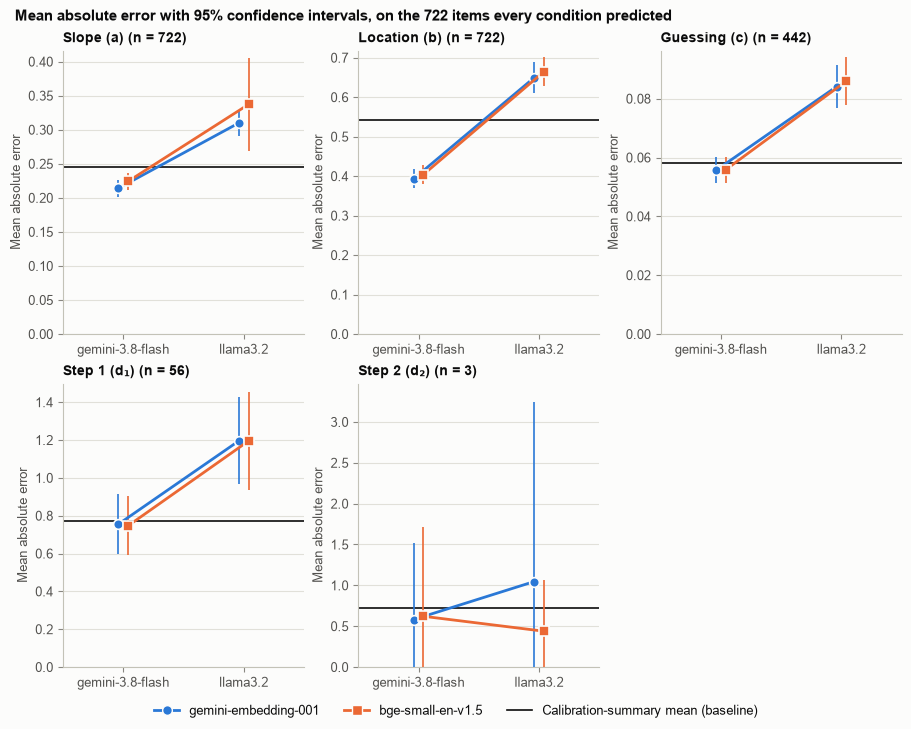

In [7]:
if factorial.common_items:
    display(plots.factorial_mae(factorial.errors, x="llm", lines="embedding_model"))
else:
    print("No item has a prediction in every condition yet")

## Export

`factorial.to_excel` writes `data/timss_math_predicted_item_parameters_compare.xlsx`, with one sheet per table:

| Sheet | Contents |
| --- | --- |
| `predictions_wide` | `factorial.wide()`: one row per item and predicted parameter, with each condition's prediction and error side by side. |
| `prediction_errors` | `factorial.errors`: one row per condition, item, and predicted parameter, with the error, its absolute value, and both baselines. |
| `predictions` | One row per condition and item: every parameter predicted and calibrated with its error, the reference items, the LLM's reasoning, token usage, and cost, and the file the prediction is saved in, which also holds the prompts. |
| `coverage` | The items each condition predicted. |
| `mae` | The mean absolute error of each condition and of the calibration-summary baseline, per parameter. |
| `effects` | The main effects and interaction, per parameter. |
| `summary` | The error summary of each condition and parameter. |
| `settings` | The embedding, index, retrieval, LLM, and evaluation settings of each condition. |

An Excel cell holds at most 32,767 characters, so a longer text, such as a long reasoning, is cut there; the saved prediction has it in full.

In [8]:
COMPARISON_PATH = DATA_DIR / "timss_math_predicted_item_parameters_compare.xlsx"

factorial.to_excel(COMPARISON_PATH)
print(f"Exported {len(wide)} item parameters of {wide['item_key'].nunique()} items in 4 conditions to {COMPARISON_PATH}")

Exported 1945 item parameters of 722 items in 4 conditions to /Users/ze/Documents/projects/timss-1/notebooks/data/timss_math_predicted_item_parameters_compare.xlsx


### Results on 2026-10-05

All four conditions predicted all 722 calibrated items.
The predictions of `bge-small-en-v1.5, gemini-3.8-flash` went to OpenRouter as 13 batches of at most 200 items, which cost $4.25 in all.
`llama3.2` needed up to six requests for a few items, because it often repeats itself until its output cap; it took about 22 seconds per item, about 9 hours for both of its conditions.

- The LLM makes almost all the difference. `llama3.2` raises the mean absolute error of every parameter with more than three items: location by 0.26, slope by 0.10, guessing by 0.03, and step 1 by 0.45 (each p < 0.001).
  It does worse than the calibration-summary baseline for every parameter, while `gemini-3.8-flash` beats the baseline for location (0.39 and 0.40 against 0.54) and slope (0.21 and 0.22 against 0.25) and is close to it for guessing and step 1.
- The embedding model makes no detectable difference. `bge-small-en-v1.5` changes the mean absolute error of location by +0.013 (95% confidence interval −0.010 to 0.035), of slope by +0.019, and of guessing by +0.001, none of them significant, so the small local model finds reference items about as useful as `gemini-embedding-001` does.
- The two factors do not interact: the LLMs differ by about as much with either embedding model (location: 0.005, p = 0.83).
- Step 2 has only the three items worth 3 points, too few to compare.
- A few of `llama3.2`'s slope predictions are extreme (RMSE 1.00 with `bge-small-en-v1.5`), which widens its slope interval.
